# GRABMyo Cross-Day sEMG Gesture Recognition — Progress Report Pipeline

In [11]:
# ============================================================
# 1. SETUP
# ============================================================
import os, sys, time, json, gc, subprocess, warnings
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/APS360_GRABMyo'
os.makedirs(DRIVE_DIR, exist_ok=True)

!pip install -q wfdb

import numpy as np
import torch
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory: %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))
else:
    print("!!! No GPU detected. Runtime > Change runtime type > select a GPU before continuing.")

N_CPUS = os.cpu_count()
print("CPUs available:", N_CPUS)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Mixed precision only pays off on GPU
USE_AMP = torch.cuda.is_available()

# ---- Reproducibility: seed everything so weight init + shuffling are repeatable ----
import random
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True         # autotune fastest conv kernels (speed)
torch.backends.cudnn.deterministic = False    # seeds still fix init + data order;
#   set benchmark=False, deterministic=True only if you ever need bit-exact repro

def seed_worker(worker_id):
    ws = torch.initial_seed() % 2**32
    np.random.seed(ws); random.seed(ws)

g_seed = torch.Generator(); g_seed.manual_seed(SEED)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch: 2.11.0+cu128 | CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory: 85.1 GB
CPUs available: 12


In [12]:
# ============================================================
# 2. CONFIG — 25 participants
# ============================================================
VERSION        = "1.0.1"
BASE_URL       = f"https://physionet.org/files/grabmyo/{VERSION}"
DATA_DIR       = os.path.join(DRIVE_DIR, "grabmyo_data")
SHARD_DIR      = os.path.join(DRIVE_DIR, "window_shards")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(SHARD_DIR, exist_ok=True)

FS           = 2048
REC_LEN      = 10240
WRIST_COLS   = [17,18,19,20,21,22, 25,26,27,28,29,30]

PARTICIPANTS = list(range(1, 26))            # 25 participants (1-22 already cached, 23-25 new)
SESSIONS     = [1, 2, 3]
GESTURES     = list(range(1, 17))
TRIALS       = list(range(1, 8))

WIN_MS, OVERLAP = 200, 0.5
WIN  = int(FS * WIN_MS/1000)
STEP = int(WIN * (1-OVERLAP))

BP_LOW, BP_HIGH, NOTCH = 20.0, 450.0, 60.0

PROCESSED_PATH = os.path.join(DRIVE_DIR, f"processed_windows_{len(PARTICIPANTS)}p.npz")
print(f"Window={WIN} samples, step={STEP} | Target: {len(PARTICIPANTS)} participants")


Window=409 samples, step=204 | Target: 25 participants


In [15]:
# ============================================================
# 3. DOWNLOAD (parallel, resumable)
# ============================================================
from concurrent.futures import ThreadPoolExecutor, as_completed
import glob

def expected_file_count():
    return len(SESSIONS) * len(GESTURES) * len(TRIALS)  # .hea count per participant

def download_session_folder(p, s, pdir):
    """One recursive wget per (participant, session) folder -- reuses a single
    connection instead of spawning a fresh process per file. This is PhysioNet's
    own documented download method (wget -r -N -c -np), just scoped to one
    participant-session folder at a time so we can parallelize across participants.
    --cut-dirs=5 strips 'files/grabmyo/{VERSION}/Session{s}/session{s}_participant{p}/'
    so files land flat in pdir, matching what process_participant() expects."""
    url = f"{BASE_URL}/Session{s}/session{s}_participant{p}/"
    subprocess.run([
        "wget", "-r", "-N", "-c", "-np", "-nH", "--cut-dirs=5",
        "-A", "*.hea,*.dat", "-R", "index.html*",
        "-q", "-P", pdir, url
    ], check=False)

def download_participant(p):
    pdir = os.path.join(DATA_DIR, f"p{p:02d}")
    os.makedirs(pdir, exist_ok=True)
    marker = os.path.join(pdir, ".done")
    n_expected_hea = expected_file_count()

    if os.path.exists(marker):
        n_hea = len(glob.glob(os.path.join(pdir, "*.hea")))
        if n_hea >= n_expected_hea * 0.9:
            return p, "cached"
        os.remove(marker)  # stale/incomplete marker (e.g. from the old wrong-URL run) -- redo

    # 3 session downloads per participant, each a single recursive wget call
    for s in SESSIONS:
        download_session_folder(p, s, pdir)

    n_hea_ok = len(glob.glob(os.path.join(pdir, "*.hea")))
    if n_hea_ok == 0:
        return p, "download_failed_zero_files"
    if n_hea_ok < n_expected_hea:
        return p, f"download_partial_{n_hea_ok}_of_{n_expected_hea}"
    open(marker, "w").close()
    return p, "downloaded"


t0 = time.time()
# Parallelize across participants -- each participant does 3 sequential recursive
# wget calls (one per session), but many participants run concurrently.
download_statuses = {}
with ThreadPoolExecutor(max_workers=6) as ex:
    futs = {ex.submit(download_participant, p): p for p in PARTICIPANTS}
    for f in as_completed(futs):
        p, status = f.result()
        download_statuses[p] = status
        print(f"participant {p}: {status}")
print(f"Download stage: {time.time()-t0:.1f}s")

bad = {p: s for p, s in download_statuses.items() if s.startswith("download_")}
if bad:
    raise RuntimeError(
        f"Download failed or was incomplete for: {bad}. This usually means the "
        f"PhysioNet URL path is wrong for this dataset version -- double check "
        f"BASE_URL/VERSION and the Session{{s}}/session{{s}}_participant{{p}}/... path "
        f"against https://physionet.org/content/grabmyo/{VERSION}/ before rerunning."
    )


participant 4: cached
participant 5: cached
participant 2: cached
participant 6: cached
participant 1: cached
participant 3: cached
participant 7: cached
participant 11: cached
participant 10: cached
participant 8: cached
participant 12: cached
participant 9: cached
participant 13: cached
participant 14: cached
participant 17: cached
participant 21: cached
participant 22: cached
participant 23: cached
participant 24: cached
participant 25: cached
participant 18: cached
participant 16: cached
participant 20: cached
participant 15: cached
participant 19: cached
Download stage: 10.8s


In [17]:
# ============================================================
# 3b. DETECT EXISTING CACHE
# ============================================================
import glob, re

BASE_CACHE_PATH, BASE_N = None, 0
candidates = glob.glob(os.path.join(DRIVE_DIR, "processed_windows_*p.npz"))
for path in candidates:
    m = re.search(r"processed_windows_(\d+)p\.npz$", os.path.basename(path))
    if not m:
        continue
    n = int(m.group(1))
    if n < len(PARTICIPANTS) and n > BASE_N:   # take the largest usable base < target
        BASE_CACHE_PATH, BASE_N = path, n

if BASE_CACHE_PATH:
    print(f"Found existing base cache: {os.path.basename(BASE_CACHE_PATH)} "
          f"-> treating as participants 1-{BASE_N} (reused, not recomputed).")
else:
    print("No existing base cache found -- all participants will be processed from scratch.")

NEW_PARTICIPANTS = [p for p in PARTICIPANTS if p > BASE_N]
print(f"New participants to process this run: {NEW_PARTICIPANTS}")


No existing base cache found -- all participants will be processed from scratch.
New participants to process this run: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


In [18]:
# ============================================================
# 4. PREPROCESS + WINDOW
# ============================================================
import wfdb
from scipy.signal import butter, sosfiltfilt, iirnotch, lfilter

_sos_bp = butter(4, [BP_LOW, BP_HIGH], btype='bandpass', fs=FS, output='sos')
_notch_b, _notch_a = iirnotch(NOTCH, Q=30, fs=FS)

def preprocess_channel(x):
    x = sosfiltfilt(_sos_bp, x)
    x = lfilter(_notch_b, _notch_a, x)
    return x

def window_signal(x):
    return [x[s:s+WIN] for s in range(0, REC_LEN - WIN + 1, STEP)]

def process_participant(p):
    """Runs in a worker process. Reads raw .hea/.dat, filters, CAR, windows,
    saves ONE shard file for this participant, returns only small metadata
    (not the array) to keep inter-process communication cheap."""
    shard_path = os.path.join(SHARD_DIR, f"p{p:02d}_shard.npz")
    if os.path.exists(shard_path):
        d = np.load(shard_path)
        return p, d["X"].shape[0], "cached"

    pdir = os.path.join(DATA_DIR, f"p{p:02d}")
    Xw, yw, sessw, triw = [], [], [], []
    for s in SESSIONS:
        for g in GESTURES:
            for t in TRIALS:
                fname = f"session{s}_participant{p}_gesture{g}_trial{t}"
                hea_path = os.path.join(pdir, fname)
                if not os.path.exists(hea_path + ".hea"):
                    continue
                rec = wfdb.rdrecord(hea_path)
                sig = rec.p_signal[:, WRIST_COLS]          # (REC_LEN, 12)
                # common-average reference across the 12 wrist channels
                sig = sig - sig.mean(axis=1, keepdims=True)
                filtered = np.stack([preprocess_channel(sig[:, c]) for c in range(sig.shape[1])], axis=1)
                wins = window_signal(filtered)
                for w in wins:
                    Xw.append(w.T.astype(np.float32))       # (12, WIN)
                    yw.append(g - 1)
                    sessw.append(s)
                    triw.append(t)
    if not Xw:
        return p, 0, "no_data_found"
    X = np.stack(Xw).astype(np.float32)
    y = np.array(yw, dtype=np.int64)
    sess = np.array(sessw, dtype=np.int64)
    tri = np.array(triw, dtype=np.int64)
    np.savez_compressed(shard_path, X=X, y=y, sess=sess, tri=tri, participant=p)
    return p, X.shape[0], "processed"

t0 = time.time()
results = []
if NEW_PARTICIPANTS:
    from concurrent.futures import ProcessPoolExecutor
    with ProcessPoolExecutor(max_workers=min(N_CPUS, len(NEW_PARTICIPANTS))) as ex:
        futs = {ex.submit(process_participant, p): p for p in NEW_PARTICIPANTS}
        for f in as_completed(futs):
            p, n, status = f.result()
            print(f"participant {p}: {status} ({n} windows)")
            results.append((p, n, status))
else:
    print(f"Participants 1-{BASE_N} covered by base cache, no new participants beyond that -- skipping preprocessing.")

failed = [p for p, n, status in results if status == "no_data_found"]
missing_shards = [p for p in NEW_PARTICIPANTS
                   if not os.path.exists(os.path.join(SHARD_DIR, f"p{p:02d}_shard.npz"))]
if failed or missing_shards:
    raise RuntimeError(
        f"Preprocessing did not produce shards for: no_data_found={failed}, "
        f"missing_on_disk={missing_shards}. Check that the raw .hea/.dat files for "
        f"these participants actually downloaded (see cell 3 output) before rerunning."
    )
print(f"Preprocessing stage: {time.time()-t0:.1f}s")


participant 2: cached (16464 windows)
participant 1: cached (16464 windows)
participant 3: cached (16464 windows)
participant 11: cached (16464 windows)
participant 9: cached (16464 windows)
participant 4: cached (16464 windows)
participant 10: cached (16464 windows)
participant 12: cached (16464 windows)
participant 5: cached (16464 windows)
participant 8: cached (16464 windows)
participant 7: cached (16464 windows)
participant 6: cached (16464 windows)
participant 16: cached (16464 windows)
participant 15: cached (16464 windows)
participant 14: cached (16464 windows)
participant 17: cached (16464 windows)
participant 21: cached (16464 windows)
participant 13: cached (16464 windows)
participant 20: cached (16464 windows)
participant 18: cached (16464 windows)
participant 22: cached (16464 windows)
participant 19: cached (16464 windows)
participant 24: cached (16464 windows)
participant 23: cached (16464 windows)
participant 25: cached (16464 windows)
Preprocessing stage: 6.4s


In [19]:
# ============================================================
# 5. MEMORY-SAFE REASSEMBLY
# ============================================================
if os.path.exists(PROCESSED_PATH):
    print("Found final cached processed windows on Drive -> loading directly.")
    d = np.load(PROCESSED_PATH)
    X, y, sess, tri, parts = d["X"], d["y"], d["sess"], d["tri"], d["parts"]
else:
    t0 = time.time()
    new_shard_paths = [(p, os.path.join(SHARD_DIR, f"p{p:02d}_shard.npz")) for p in NEW_PARTICIPANTS]
    missing = [p for p, sp in new_shard_paths if not os.path.exists(sp)]
    if missing:
        raise RuntimeError(
            f"Missing shard file(s) for participant(s) {missing} in {SHARD_DIR}. "
            f"Re-run cell 4 (preprocessing) fully before this cell -- it must finish "
            f"without error for every participant in NEW_PARTICIPANTS={NEW_PARTICIPANTS}."
        )

    # ---- Pass 1: figure out total size without loading any big arrays yet ----
    base_n = 0
    base_has_parts = False
    if BASE_CACHE_PATH:
        with np.load(BASE_CACHE_PATH) as d:
            base_n = d["X"].shape[0]
            base_has_parts = "parts" in d.files

    new_shapes = []
    for p, sp in new_shard_paths:
        with np.load(sp) as d:
            new_shapes.append(d["X"].shape[0])

    total_n = base_n + sum(new_shapes)

    # ---- Pass 2: preallocate once, then stream each source into its slice ----
    X    = np.empty((total_n, 12, WIN), dtype=np.float32)
    y    = np.empty(total_n, dtype=np.int64)
    sess = np.empty(total_n, dtype=np.int64)
    tri  = np.empty(total_n, dtype=np.int64)
    parts = np.empty(total_n, dtype=np.int64)

    idx = 0
    if BASE_CACHE_PATH and base_n > 0:
        with np.load(BASE_CACHE_PATH) as d:
            X[idx:idx+base_n]    = d["X"]
            y[idx:idx+base_n]    = d["y"]
            sess[idx:idx+base_n] = d["sess"]
            tri[idx:idx+base_n]  = d["tri"]
            parts[idx:idx+base_n] = d["parts"] if base_has_parts else 0   # unknown-participant marker
        idx += base_n
        gc.collect()
        print(f"Streamed base cache: {base_n} windows (participants 1-{BASE_N})")

    for p, sp in new_shard_paths:
        with np.load(sp) as d:
            n = d["X"].shape[0]
            X[idx:idx+n]    = d["X"]
            y[idx:idx+n]    = d["y"]
            sess[idx:idx+n] = d["sess"]
            tri[idx:idx+n]  = d["tri"]
            parts[idx:idx+n] = p
        idx += n
        gc.collect()
        print(f"Streamed participant {p}: {n} windows")

    np.savez_compressed(PROCESSED_PATH, X=X, y=y, sess=sess, tri=tri, parts=parts)
    print(f"Reassembly stage: {time.time()-t0:.1f}s")

print("Total windows:", X.shape[0], "| shape:", X.shape)


Found final cached processed windows on Drive -> loading directly.
Total windows: 411600 | shape: (411600, 12, 409)


In [20]:
# ============================================================
# 6. SPLITS — trial/session-level, leakage-controlled.
# ============================================================

# --- Cross-day: train on Days 1-2 (trials 1-6), validate on a held-out full
#     trial (7) from those days, test on the fully unseen Day 3.
cross_train_mask = (sess != 3) & np.isin(tri, [1, 2, 3, 4, 5, 6])
cross_val_mask   = (sess != 3) & np.isin(tri, [7])
cross_test_mask  = (sess == 3)

# --- Same-day: within Days 1-2, split by WHOLE trials:
#     train {1,2,3,5}, validation {6}, test {4,7}.
same_train_mask = (sess != 3) & np.isin(tri, [1, 2, 3, 5])
same_val_mask   = (sess != 3) & np.isin(tri, [6])
same_test_mask  = (sess != 3) & np.isin(tri, [4, 7])

def report_split(name, tr, va, te):
    print(f"{name}: train={int(tr.sum())}  val={int(va.sum())}  test={int(te.sum())}")
report_split("Same-day ", same_train_mask, same_val_mask, same_test_mask)
report_split("Cross-day", cross_train_mask, cross_val_mask, cross_test_mask)

# ---- Per-protocol, TRAIN-ONLY normalizers (no val/test windows leak in) ----
def make_normalizer(train_mask):
    mu  = X[train_mask].mean(axis=(0, 2)).astype(np.float32)[:, None]        # (12,1)
    std = (X[train_mask].std(axis=(0, 2)).astype(np.float32) + 1e-8)[:, None]
    return mu, std

mu_same,  std_same  = make_normalizer(same_train_mask)
mu_cross, std_cross = make_normalizer(cross_train_mask)
print("Normalizers fit on TRAIN windows only, separately for same-day and cross-day.")


Same-day : train=156800  val=39200  test=78400
Cross-day: train=235200  val=39200  test=137200
Normalizers fit on TRAIN windows only, separately for same-day and cross-day.


In [21]:
# ============================================================
# 7. SVM BASELINE
# ============================================================
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

def hudgins_features(x):
    # x: (12, WIN), already normalized
    rms = np.sqrt((x**2).mean(axis=1))
    mav = np.abs(x).mean(axis=1)
    wl  = np.abs(np.diff(x, axis=1)).sum(axis=1)
    zc  = ((x[:, :-1] * x[:, 1:]) < 0).sum(axis=1).astype(np.float32)
    return np.concatenate([rms, mav, wl, zc])   # 12*4 = 48-dim

SVM_CAP = 12000  # RBF-SVM hangs at full scale -> capped, honestly caveated in report

def make_svm_data(train_mask, test_mask, mu, std, cap=SVM_CAP, seed=0):
    tr_idx = np.where(train_mask)[0]
    te_idx = np.where(test_mask)[0]
    r = np.random.RandomState(seed)
    if len(tr_idx) > cap:
        tr_idx = r.choice(tr_idx, size=cap, replace=False)
    Xtr = np.stack([hudgins_features((X[i] - mu) / std) for i in tr_idx])
    Xte = np.stack([hudgins_features((X[i] - mu) / std) for i in te_idx])
    ytr, yte = y[tr_idx], y[te_idx]
    return Xtr, ytr, Xte, yte, len(tr_idx), len(te_idx)

def run_svm(train_mask, test_mask, mu, std, tag):
    t0 = time.time()
    Xtr, ytr, Xte, yte, n_tr, n_te = make_svm_data(train_mask, test_mask, mu, std)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)
    clf = SVC(kernel='rbf', C=10, gamma='scale')
    clf.fit(Xtr_s, ytr)
    pred = clf.predict(Xte_s)
    acc = accuracy_score(yte, pred)
    f1  = f1_score(yte, pred, average='macro')
    cm  = confusion_matrix(yte, pred)
    print(f"[SVM/{tag}] train_n={n_tr} (capped) test_n={n_te} acc={acc:.4f} macroF1={f1:.4f}  ({time.time()-t0:.1f}s)")
    return {"tag": tag, "acc": float(acc), "macro_f1": float(f1), "cm": cm.tolist(),
            "train_n": n_tr, "test_n": n_te}

svm_same  = run_svm(same_train_mask,  same_test_mask,  mu_same,  std_same,  "same_day")
svm_cross = run_svm(cross_train_mask, cross_test_mask, mu_cross, std_cross, "cross_day")


[SVM/same_day] train_n=12000 (capped) test_n=78400 acc=0.6646 macroF1=0.6648  (85.4s)
[SVM/cross_day] train_n=12000 (capped) test_n=137200 acc=0.5098 macroF1=0.5084  (150.0s)


In [22]:
# ============================================================
# 8. 1D CNN
# ============================================================
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class EMGDataset(Dataset):
    """Applies the given (train-only) normalizer on the fly, so no full
    normalized copy of X is held in RAM and no val/test stats can leak in."""
    def __init__(self, X, y, idx, mu, std):
        self.X = X; self.y = y; self.idx = idx
        self.mu = mu.astype(np.float32); self.std = std.astype(np.float32)
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        x = (self.X[j] - self.mu) / self.std
        return torch.from_numpy(x.astype(np.float32)), int(self.y[j])

class EMGCNN(nn.Module):
    def __init__(self, n_channels=12, n_classes=16, dropout=0.3):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, kernel_size=5, padding=2),
                nn.BatchNorm1d(c_out),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(2))
        self.b1 = block(n_channels, 32)
        self.b2 = block(32, 64)
        self.b3 = block(64, 128)
        self.drop = nn.Dropout(dropout)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, n_classes)
    def forward(self, x):
        x = self.b1(x); x = self.b2(x); x = self.b3(x)
        x = self.gap(x).squeeze(-1)
        x = self.drop(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

N_PARAMS = sum(p.numel() for p in EMGCNN().parameters() if p.requires_grad)
print(f"1D CNN trainable parameters: {N_PARAMS:,}")


1D CNN trainable parameters: 63,088


In [23]:
# ============================================================
# 9. CNN TRAINING
# ============================================================
BATCH_SIZE   = 256 if torch.cuda.is_available() else 64
NUM_WORKERS  = min(4, N_CPUS)
EPOCHS_MAX   = 60
PATIENCE     = 8
CKPT_PATH    = os.path.join(DRIVE_DIR, f"cnn_ckpt_{len(PARTICIPANTS)}p.pt")

scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_cnn(train_mask, val_mask, test_mask, mu, std, tag):
    tr_idx  = np.where(train_mask)[0]
    val_idx = np.where(val_mask)[0]
    te_idx  = np.where(test_mask)[0]

    train_ds = EMGDataset(X, y, tr_idx,  mu, std)
    val_ds   = EMGDataset(X, y, val_idx, mu, std)
    test_ds  = EMGDataset(X, y, te_idx,  mu, std)

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
                          persistent_workers=NUM_WORKERS > 0, drop_last=True,
                          worker_init_fn=seed_worker, generator=g_seed)
    val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

    model = EMGCNN().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)
    crit = nn.CrossEntropyLoss()

    best_f1, best_state, bad_epochs = -1, None, 0
    history = {"train_loss": [], "val_f1": []}
    t0 = time.time()
    for epoch in range(EPOCHS_MAX):
        model.train()
        run_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out = model(xb)
                loss = crit(out, yb)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(opt)
            scaler_amp.update()
            run_loss += loss.item() * xb.size(0)
        run_loss /= len(train_ds)

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in val_dl:
                xb = xb.to(DEVICE, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    out = model(xb)
                preds.append(out.argmax(1).cpu().numpy()); trues.append(yb.numpy())
        preds, trues = np.concatenate(preds), np.concatenate(trues)
        val_f1 = f1_score(trues, preds, average='macro')
        sched.step(val_f1)
        history["train_loss"].append(run_loss); history["val_f1"].append(val_f1)

        if val_f1 > best_f1:
            best_f1, bad_epochs = val_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
        if epoch % 5 == 0 or bad_epochs == 0:
            print(f"  [{tag}] epoch {epoch:02d}  train_loss={run_loss:.4f}  val_macroF1={val_f1:.4f}")
        if bad_epochs >= PATIENCE:
            print(f"  [{tag}] early stop at epoch {epoch} (best val_macroF1={best_f1:.4f})")
            break

    model.load_state_dict(best_state)
    torch.save(best_state, CKPT_PATH.replace(".pt", f"_{tag}.pt"))

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out = model(xb)
            preds.append(out.argmax(1).cpu().numpy()); trues.append(yb.numpy())
    preds, trues = np.concatenate(preds), np.concatenate(trues)
    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average='macro')
    cm  = confusion_matrix(trues, preds)
    elapsed = time.time() - t0
    print(f"[CNN/{tag}] test acc={acc:.4f} macroF1={f1:.4f}  ({elapsed:.1f}s, {epoch+1} epochs)")
    return {"tag": tag, "acc": float(acc), "macro_f1": float(f1), "cm": cm.tolist(),
            "best_val_f1": float(best_f1), "epochs_run": epoch+1,
            "history": history, "train_n": len(tr_idx), "val_n": len(val_idx), "test_n": len(te_idx)}

cnn_same  = train_cnn(same_train_mask,  same_val_mask,  same_test_mask,  mu_same,  std_same,  "same_day")
cnn_cross = train_cnn(cross_train_mask, cross_val_mask, cross_test_mask, mu_cross, std_cross, "cross_day")


  [same_day] epoch 00  train_loss=1.2738  val_macroF1=0.6675
  [same_day] epoch 01  train_loss=0.8852  val_macroF1=0.6960
  [same_day] epoch 02  train_loss=0.7810  val_macroF1=0.7270
  [same_day] epoch 04  train_loss=0.6664  val_macroF1=0.7474
  [same_day] epoch 05  train_loss=0.6285  val_macroF1=0.7829
  [same_day] epoch 06  train_loss=0.6012  val_macroF1=0.7847
  [same_day] epoch 08  train_loss=0.5508  val_macroF1=0.7856
  [same_day] epoch 09  train_loss=0.5341  val_macroF1=0.8015
  [same_day] epoch 10  train_loss=0.5185  val_macroF1=0.8160
  [same_day] epoch 15  train_loss=0.4319  val_macroF1=0.8368
  [same_day] epoch 20  train_loss=0.3903  val_macroF1=0.8390
  [same_day] epoch 21  train_loss=0.3838  val_macroF1=0.8437
  [same_day] epoch 25  train_loss=0.3775  val_macroF1=0.8430
  [same_day] epoch 27  train_loss=0.3645  val_macroF1=0.8445
  [same_day] epoch 30  train_loss=0.3611  val_macroF1=0.8459
  [same_day] epoch 31  train_loss=0.3615  val_macroF1=0.8483
  [same_day] epoch 33  t

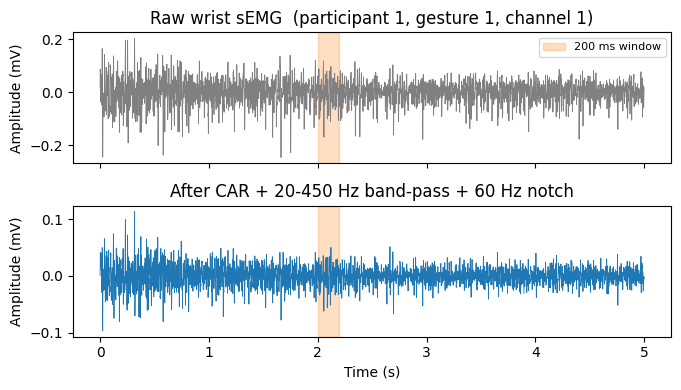

Saved cleaned_sample.png


In [24]:
# ============================================================
# 9b. CLEANED-SAMPLE FIGURE
# ============================================================
import matplotlib.pyplot as plt
import wfdb

_ex_p, _ex_s, _ex_g, _ex_t = PARTICIPANTS[0], SESSIONS[0], GESTURES[0], TRIALS[0]
_ex_name = f"session{_ex_s}_participant{_ex_p}_gesture{_ex_g}_trial{_ex_t}"
_ex_path = os.path.join(DATA_DIR, f"p{_ex_p:02d}", _ex_name)
try:
    _rec = wfdb.rdrecord(_ex_path)
    _sig = _rec.p_signal[:, WRIST_COLS]                 # (REC_LEN, 12)
    _car = _sig - _sig.mean(axis=1, keepdims=True)
    _ch = 0
    _raw = _sig[:, _ch]
    _clean = preprocess_channel(_car[:, _ch])
    _t = np.arange(len(_raw)) / FS

    fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
    axes[0].plot(_t, _raw, color="0.5", lw=0.6)
    axes[0].set_title(f"Raw wrist sEMG  (participant {_ex_p}, gesture {_ex_g}, channel {_ch+1})")
    axes[0].set_ylabel("Amplitude (mV)")
    axes[1].plot(_t, _clean, color="tab:blue", lw=0.6)
    axes[1].set_title("After CAR + 20-450 Hz band-pass + 60 Hz notch")
    axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Amplitude (mV)")
    _w0 = int(len(_raw) * 0.4); _w1 = min(_w0 + WIN, len(_raw) - 1)
    for _ax in axes:
        _ax.axvspan(_t[_w0], _t[_w1], color="tab:orange", alpha=0.25, label="200 ms window")
    axes[0].legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    fig.savefig(os.path.join(DRIVE_DIR, "cleaned_sample.png"), dpi=150)
    plt.show()
    print("Saved cleaned_sample.png")
except FileNotFoundError:
    print(f"Raw record not found at {_ex_path} -- re-run the download cell (raw .hea/.dat "
          f"must be on Drive) to generate the cleaned-sample figure.")


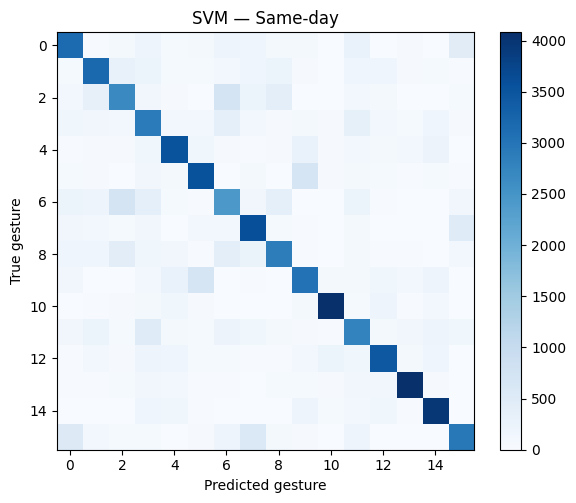

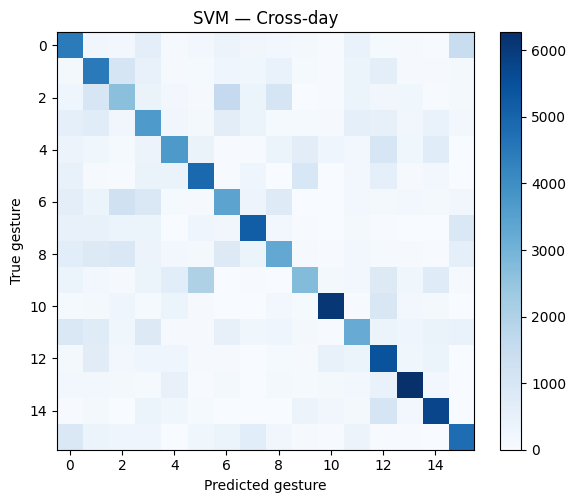

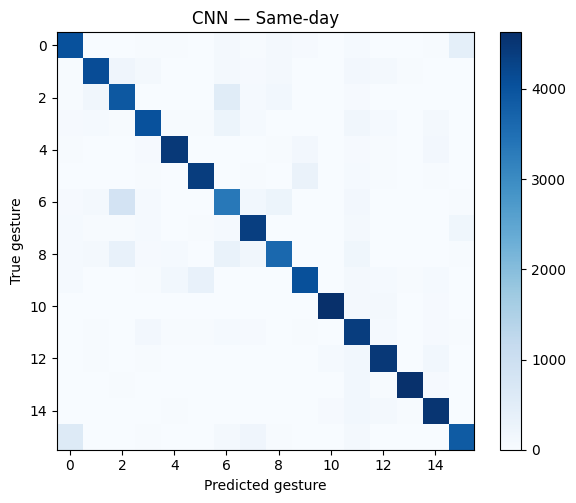

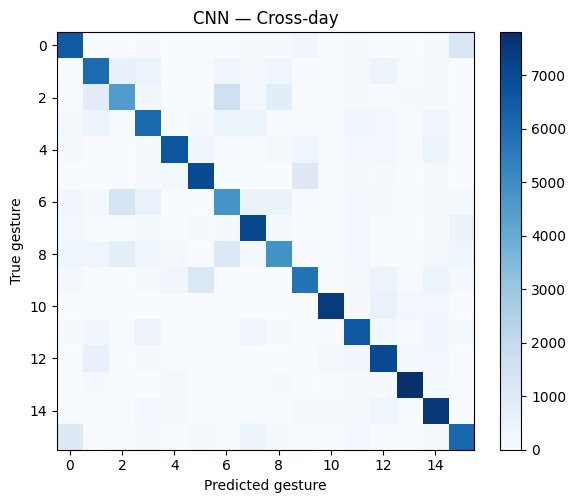

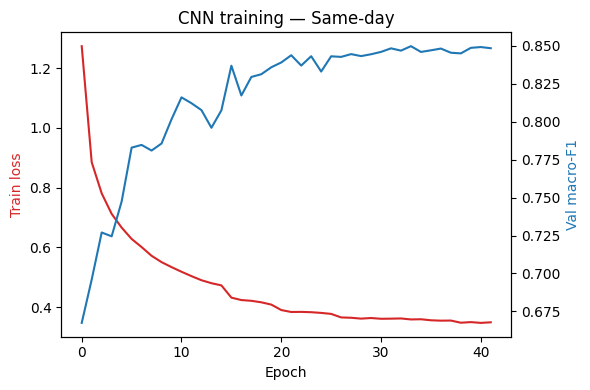

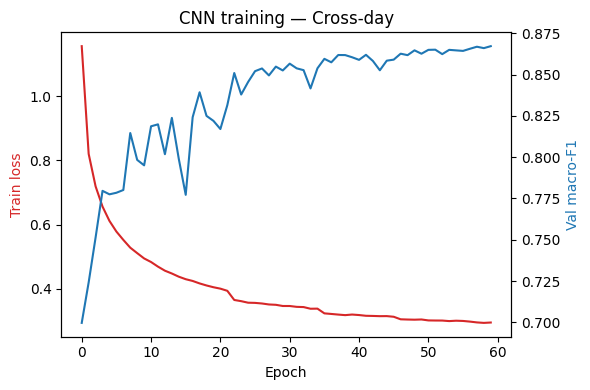

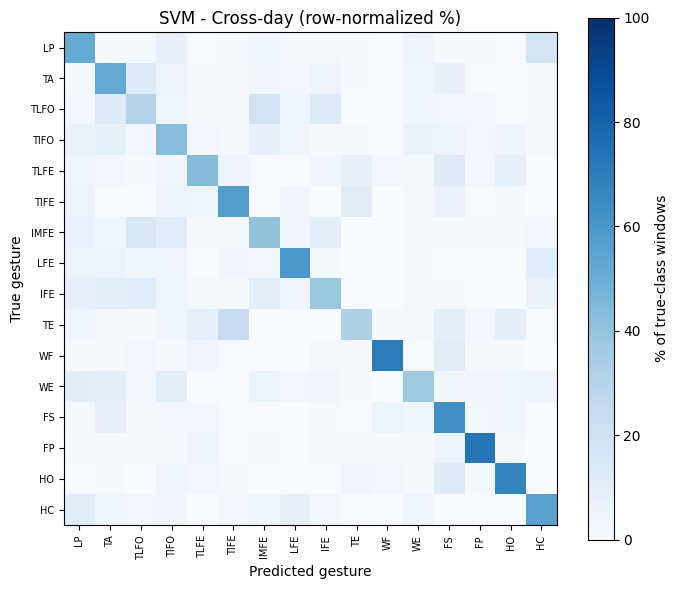

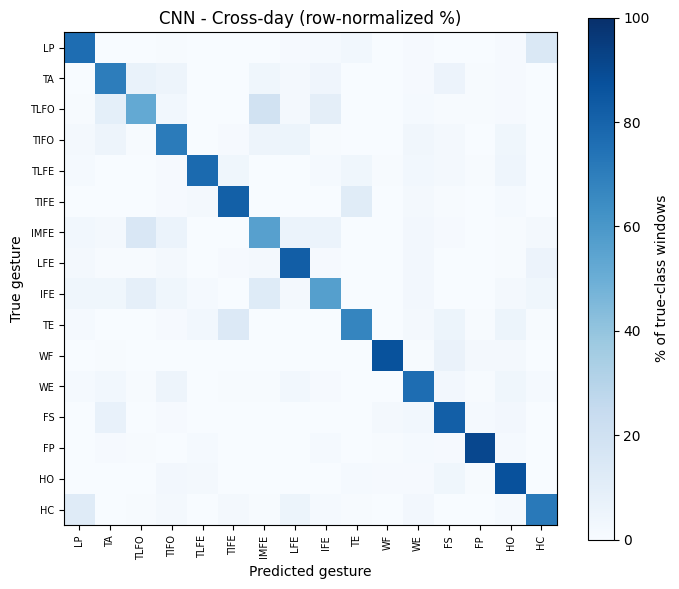


Top cross-day confusions (SVM):
  true TE -> predicted TIFE: 23.7%
  true TLFO -> predicted IMFE: 18.4%
  true LP -> predicted HC: 17.0%
  true IMFE -> predicted TLFO: 14.4%
  true TLFO -> predicted IFE: 12.4%
  true TA -> predicted TLFO: 12.3%

Top cross-day confusions (CNN):
  true TLFO -> predicted IMFE: 19.0%
  true IMFE -> predicted TLFO: 15.0%
  true LP -> predicted HC: 14.5%
  true TE -> predicted TIFE: 13.5%
  true IFE -> predicted IMFE: 12.3%
  true HC -> predicted LP: 11.8%


In [25]:
# ============================================================
# 10. FIGURES — confusion matrices + training curves
# ============================================================
import matplotlib.pyplot as plt

def plot_cm(cm, title, fname):
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted gesture')
    ax.set_ylabel('True gesture')
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(os.path.join(DRIVE_DIR, fname), dpi=150)
    plt.show()

plot_cm(np.array(svm_same["cm"]),  "SVM — Same-day", "cm_svm_same.png")
plot_cm(np.array(svm_cross["cm"]), "SVM — Cross-day", "cm_svm_cross.png")
plot_cm(np.array(cnn_same["cm"]),  "CNN — Same-day", "cm_cnn_same.png")
plot_cm(np.array(cnn_cross["cm"]), "CNN — Cross-day", "cm_cnn_cross.png")

def plot_curve(history, title, fname):
    fig, ax1 = plt.subplots(figsize=(6,4))
    ax1.plot(history["train_loss"], label="Train loss", color="tab:red")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train loss", color="tab:red")
    ax2 = ax1.twinx()
    ax2.plot(history["val_f1"], label="Val macro-F1", color="tab:blue")
    ax2.set_ylabel("Val macro-F1", color="tab:blue")
    ax1.set_title(title)
    fig.tight_layout()
    fig.savefig(os.path.join(DRIVE_DIR, fname), dpi=150)
    plt.show()

plot_curve(cnn_same["history"],  "CNN training — Same-day",  "curve_cnn_same.png")
plot_curve(cnn_cross["history"], "CNN training — Cross-day", "curve_cnn_cross.png")

GESTURE_LABELS = ["LP","TA","TLFO","TIFO","TLFE","TIFE","IMFE","LFE",
                  "IFE","TE","WF","WE","FS","FP","HO","HC"]

def plot_cm_pct(cm, title, fname):
    cm = np.array(cm, dtype=float)
    row = cm.sum(axis=1, keepdims=True); row[row == 0] = 1
    cmp = 100.0 * cm / row
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cmp, cmap='Blues', vmin=0, vmax=100)
    ax.set_title(title)
    ax.set_xlabel('Predicted gesture'); ax.set_ylabel('True gesture')
    ax.set_xticks(range(16)); ax.set_yticks(range(16))
    ax.set_xticklabels(GESTURE_LABELS, rotation=90, fontsize=7)
    ax.set_yticklabels(GESTURE_LABELS, fontsize=7)
    cb = fig.colorbar(im, ax=ax); cb.set_label('% of true-class windows')
    fig.tight_layout()
    fig.savefig(os.path.join(DRIVE_DIR, fname), dpi=160)
    plt.show()

plot_cm_pct(svm_cross["cm"], "SVM - Cross-day (row-normalized %)", "cm_svm_cross_pct.png")
plot_cm_pct(cnn_cross["cm"], "CNN - Cross-day (row-normalized %)", "cm_cnn_cross_pct.png")

# ---- Print the largest cross-day confusion pairs so the report can NAME them ----
def top_confusions(cm, k=6):
    cm = np.array(cm, dtype=float)
    row = cm.sum(axis=1, keepdims=True); row[row == 0] = 1
    cmp = 100.0 * cm / row
    pairs = [(cmp[i, j], i, j) for i in range(16) for j in range(16) if i != j]
    pairs.sort(reverse=True)
    return pairs[:k]

for _name, _r in [("SVM", svm_cross), ("CNN", cnn_cross)]:
    print(f"\nTop cross-day confusions ({_name}):")
    for pct, i, j in top_confusions(_r["cm"]):
        print(f"  true {GESTURE_LABELS[i]} -> predicted {GESTURE_LABELS[j]}: {pct:.1f}%")


In [26]:
# ============================================================
# 11. SAVE results.json
# ============================================================
results_summary = {
    "n_participants": len(PARTICIPANTS),
    "new_participants_this_run": NEW_PARTICIPANTS,
    "total_windows": int(X.shape[0]),
    "cnn_trainable_params": int(N_PARAMS),
    "svm_same_day":  {k: v for k, v in svm_same.items()  if k != "cm"},
    "svm_cross_day": {k: v for k, v in svm_cross.items() if k != "cm"},
    "cnn_same_day":  {k: v for k, v in cnn_same.items()  if k not in ("cm","history")},
    "cnn_cross_day": {k: v for k, v in cnn_cross.items() if k not in ("cm","history")},
    "cross_day_generalization_gap": {
        "svm": float(svm_same["acc"] - svm_cross["acc"]),
        "cnn": float(cnn_same["acc"] - cnn_cross["acc"]),
    },
}
out_path = os.path.join(DRIVE_DIR, "results.json")
with open(out_path, "w") as f:
    json.dump(results_summary, f, indent=2)

print(json.dumps(results_summary, indent=2))
print(f"\nSaved to: {out_path}")
print("Figures on Drive for the report:")
print("  cleaned_sample.png                         (Data Processing)")
print("  cm_svm_cross_pct.png, cm_cnn_cross_pct.png (Qualitative Results, row-normalized)")
print("  curve_cnn_same.png, curve_cnn_cross.png    (training curves)")
print("  (raw-count cm_*_same/cross.png also saved if you want them)")


{
  "n_participants": 25,
  "new_participants_this_run": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25
  ],
  "total_windows": 411600,
  "cnn_trainable_params": 63088,
  "svm_same_day": {
    "tag": "same_day",
    "acc": 0.6645918367346939,
    "macro_f1": 0.6648110850586679,
    "train_n": 12000,
    "test_n": 78400
  },
  "svm_cross_day": {
    "tag": "cross_day",
    "acc": 0.5098469387755102,
    "macro_f1": 0.5083620999948737,
    "train_n": 12000,
    "test_n": 137200
  },
  "cnn_same_day": {
    "tag": "same_day",
    "acc": 0.8521683673469388,
    "macro_f1": 0.8523990281145832,
    "best_val_f1": 0.8496927316700571,
    "epochs_run": 42,
    "train_n": 156800,
    "val_n": 39200,
    "test_n": 78400
  },
  "cnn_cross_day": {
    "tag": "cross_day",
    "acc": 0.7409839650145773,
    "macro_f1": 0.7396400942696835,
    "best_val_f1":